In [1]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [2]:
# Libraries
import pandas as pd
import numpy as np
import gpxpy

In [3]:
# Other helpers

from helper_functions.gpx_to_tabular import (
    SLOPE_CATEGORIES,
    classify_slope,
    gpx_to_tabular,
    plot_course_profile
)

---
# UTMB Course Analysis

Prepare UTMB course data

In [4]:
# Import UTMB GPX

gpx_file_path = "utmb_2025_course.gpx"
with open(gpx_file_path, "r") as f:
    utmb_gpx = gpxpy.parse(f)

In [5]:
# UTMB GPX to Tabular
utmb_course_df = gpx_to_tabular(utmb_gpx)

About

In [ ]:
# About - Slope categories
for key, value_pair in SLOPE_CATEGORIES.items():
    print(f"- {key}: {value_pair} % slope")

- Flat: (0, 1) % slope
- Very easy: (1, 3) % slope
- Easy: (3, 7) % slope
- Moderate: (7, 12) % slope
- Steep: (12, 20) % slope
- Very steep: (20, 30) % slope
- Extreme: (30, inf) % slope


In [31]:
# About ~ Profile
print("About UTMB Course ~ 2025 GPX")
print("----------------------------------------")

print("\nTotal:")
print("Distance = {:,.0f} [km]".format(utmb_course_df["point_distance_2d_m"].sum()))
print("Elevation gain = {:,.0f} [m]".format(utmb_course_df["point_elevation_gain_m"].sum()))
print("Elevation loss = {:,.0f} [m]".format(utmb_course_df["point_elevation_loss_m"].sum()))

elevation_per_kilometer = utmb_course_df["total_elevation_gain_m"].max() / (utmb_course_df["total_distance_2d_m"].max() / 1_000)
print("Elevation per kilometer = {:.2f}m".format(elevation_per_kilometer))
print("Elevation for kilometer uphill (loop course) = {:.2f}m".format(elevation_per_kilometer * 2))

print("\nFlat slopes:")
utmb_course_df_flat = utmb_course_df[utmb_course_df["slope_class"] == "Flat"].reset_index(drop=True)
print("Proportion = {:.2f}%".format(utmb_course_df_flat["point_distance_2d_m"].sum() / utmb_course_df["point_distance_2d_m"].sum() * 100))
print("Avg. slope ~ mean = {:.2f}%".format(utmb_course_df_flat["slope_perc"].mean()))
print("Avg. slope ~ distance = {:.2f}%".format((utmb_course_df_flat["slope_perc"] * utmb_course_df_flat["point_distance_2d_m"]).sum() / utmb_course_df_flat["point_distance_2d_m"].sum()))

print("\nUphill slopes:")
utmb_course_df_uphill = utmb_course_df[utmb_course_df["slope_class"].str.contains("Uphill")].reset_index(drop=True)
print("Proportion = {:.2f}%".format(utmb_course_df_uphill["point_distance_2d_m"].sum() / utmb_course_df["point_distance_2d_m"].sum() * 100))
print("Avg. slope ~ mean = {:.2f}%".format(utmb_course_df_uphill["slope_perc"].mean()))
print("Avg. slope ~ distance = {:.2f}%".format((utmb_course_df_uphill["slope_perc"] * utmb_course_df_uphill["point_distance_2d_m"]).sum() / utmb_course_df_uphill["point_distance_2d_m"].sum()))
print("----------------------------")
for slope_class, proportion in (utmb_course_df_uphill["slope_class"].value_counts(normalize=True) * 100).items():
    print("{} ~> {:.2f}%".format(slope_class.replace("Uphill | ", ""), proportion))

print("\nDownhill slopes:")
utmb_course_df_downhill = utmb_course_df[utmb_course_df["slope_class"].str.contains("Downhill")].reset_index(drop=True)
print("Proportion = {:.2f}%".format(utmb_course_df_downhill["point_distance_2d_m"].sum() / utmb_course_df["point_distance_2d_m"].sum() * 100))
print("Avg. slope ~ mean = {:.2f}%".format(abs(utmb_course_df_downhill["slope_perc"].mean())))
print("Avg. slope ~ distance = {:.2f}%".format((utmb_course_df_downhill["slope_perc"] * utmb_course_df_downhill["point_distance_2d_m"]).sum() / utmb_course_df_downhill["point_distance_2d_m"].sum()))
print("----------------------------")
for slope_class, proportion in (utmb_course_df_downhill["slope_class"].value_counts(normalize=True) * 100).items():
    print("{} ~> {:.2f}%".format(slope_class.replace("Downhill | ", ""), proportion))

About UTMB Course ~ 2025 GPX
----------------------------------------

Total:
Distance = 172,625 [km]
Elevation gain = 10,510 [m]
Elevation loss = 10,509 [m]
Elevation per kilometer = 60.88m
Elevation for kilometer uphill (loop course) = 121.76m

Flat slopes:
Proportion = 8.18%
Avg. slope ~ mean = -0.01%
Avg. slope ~ distance = -0.04%

Uphill slopes:
Proportion = 46.71%
Avg. slope ~ mean = 20.50%
Avg. slope ~ distance = 12.99%
----------------------------
Steep ~> 27.90%
Very steep ~> 23.40%
Extreme ~> 16.80%
Moderate ~> 16.74%
Easy ~> 10.61%
Very easy ~> 4.55%

Downhill slopes:
Proportion = 45.10%
Avg. slope ~ mean = 18.72%
Avg. slope ~ distance = -13.46%
----------------------------
Steep ~> 26.31%
Very steep ~> 21.51%
Moderate ~> 16.60%
Extreme ~> 15.11%
Easy ~> 13.75%
Very easy ~> 6.73%


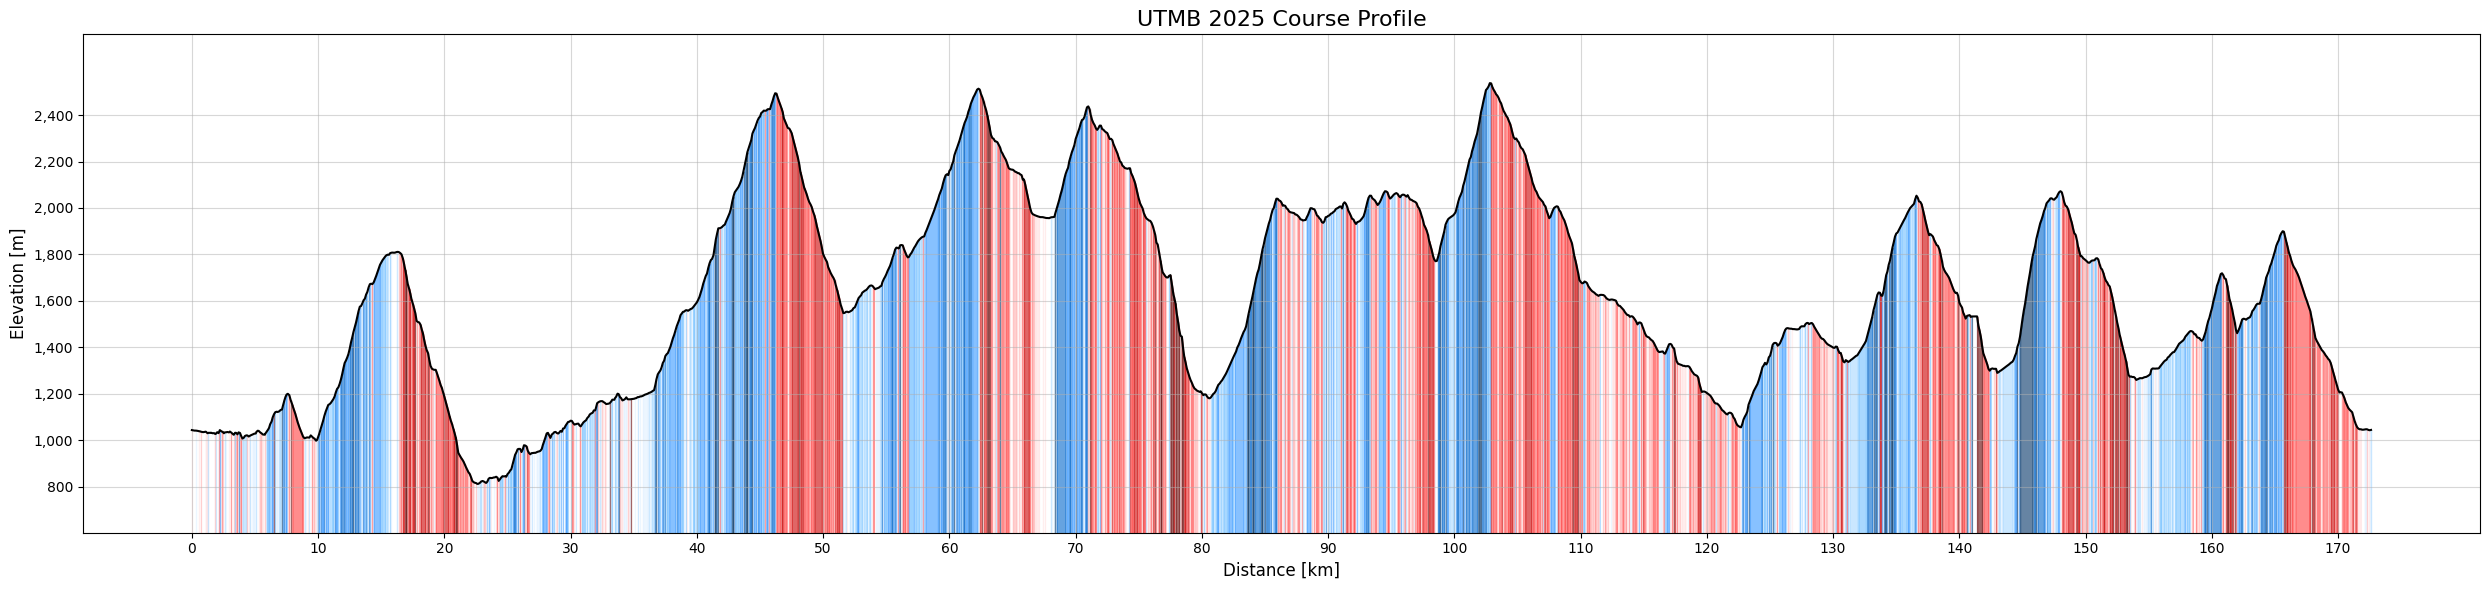

- Flat: (0, 1) % slope
- Very easy: (1, 3) % slope
- Easy: (3, 7) % slope
- Moderate: (7, 12) % slope
- Steep: (12, 20) % slope
- Very steep: (20, 30) % slope
- Extreme: (30, inf) % slope


In [32]:
# Plot
plot_course_profile(
    gpx_tabular_df = utmb_course_df, 
    course_name = "UTMB 2025 Course Profile", 
    slope_categories = SLOPE_CATEGORIES
)

for key, value_pair in SLOPE_CATEGORIES.items():
    print(f"- {key}: {value_pair} % slope")

In [20]:
# Goal time pace requirements
def _required_pace_min_km(
    length_km: float, 
    goal_time_minutes: float
) -> float:

        return goal_time_minutes / length_km

length = utmb_course_df["total_distance_2d_m"].max() / 1000
required_pace_21h = _required_pace_min_km(length, 21 * 60)


print("Required pace for Top 10 race time of {:.1f}h: {:.2f} min/km".format(21, _required_pace_min_km(length, 21 * 60)))
print("Required pace for Average race time of {:.1f}h: {:.2f} min/km".format(39, _required_pace_min_km(length, 39 * 60)))
print("Required pace for Median race time of {:.1f}h: {:.2f} min/km".format(40.5, _required_pace_min_km(length, 40.5 * 60)))
print("Required pace for Cutoff race time of {:.1f}h: {:.2f} min/km".format(46, _required_pace_min_km(length, 46 * 60)))

Required pace for Top 10 race time of 21.0h: 7.30 min/km
Required pace for Average race time of 39.0h: 13.56 min/km
Required pace for Median race time of 40.5h: 14.08 min/km
Required pace for Cutoff race time of 46.0h: 15.99 min/km
